# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Atur gaya visualisasi
sns.set_style("whitegrid")

# Data Acquistion

In [ ]:
# Akuisisi Data
try:
    df = pd.read_csv('Sales Transaction v.4a.csv', encoding='ISO-8859-1')
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'Sales Transaction v.4a.csv' tidak ditemukan")
    df = None
except UnicodeDecodeError:
    print("Error: Gagal membaca file. Mencoba dengan encoding 'ISO-8859-1'.")
    df = pd.read_csv('Sales Transaction v.4a.csv', encoding='ISO-8859-1')

# Tampilkan 5 baris pertama, describe, dan info umum
if df is not None:
    print("\n--- 5 Baris Pertama Dataset ---")
    print(df.head())

    # TAMBAHAN: df.describe()
    print("\n--- Statistik Deskriptif Dataset (df.describe()) ---")
    print(df.describe())

    # df.info() (Sudah ada, dipindahkan ke sini)
    print("\n--- Informasi Umum Dataset (df.info()) ---")
    df.info()

Dataset berhasil dimuat.

--- 5 Baris Pertama Dataset ---
  TransactionNo       Date ProductNo                          ProductName  \
0        581482  12/9/2019     22485        Set Of 2 Wooden Market Crates   
1        581475  12/9/2019     22596  Christmas Star Wish List Chalkboard   
2        581475  12/9/2019     23235             Storage Tin Vintage Leaf   
3        581475  12/9/2019     23272    Tree T-Light Holder Willie Winkie   
4        581475  12/9/2019     23239    Set Of 4 Knick Knack Tins Poppies   

   Price  Quantity  CustomerNo         Country  
0  21.47        12     17490.0  United Kingdom  
1  10.65        36     13069.0  United Kingdom  
2  11.53        12     13069.0  United Kingdom  
3  10.65        12     13069.0  United Kingdom  
4  11.94         6     13069.0  United Kingdom  

--- Statistik Deskriptif Dataset (df.describe()) ---
               Price       Quantity     CustomerNo
count  536350.000000  536350.000000  536295.000000
mean       12.662182       9.

# Pembersihan Data

## Penamaan Kolom, Tipe Data & Missing Values

In [ ]:
if df is not None:
    # 1. Penamaan Ulang Kolom
    df.rename(columns={
        'TransactionNo': 'InvoiceNo',
        'Date': 'InvoiceDate',
        'ProductNo': 'StockCode',
        'ProductName': 'Description',
        'Price': 'UnitPrice',
        'CustomerNo': 'CustomerID'
    }, inplace=True)

    # 2. Konversi Tipe Data
    # Konversi InvoiceDate ke datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Konversi CustomerID ke string
    df['CustomerID'] = df['CustomerID'].astype(str)

    # Pastikan Price dan Quantity adalah numerik
    df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

    # 3. Penanganan Missing Values (NaN)
    print("\n--- Jumlah Missing Values (Sebelum Penanganan) ---")
    print(df.isnull().sum())

    # Strategi 1: Hapus baris dengan CustomerID hilang
    # Missing CustomerID membuat analisis pelanggan
    df_cleaned = df.dropna(subset=['CustomerID'])

    # Strategi 2: Isi/Hapus Missing Values lainnya
    # Hapus baris dengan Quantity atau UnitPrice yang hilang
    df_cleaned = df_cleaned.dropna(subset=['Quantity', 'UnitPrice'])

    # Hapus baris dengan Description yang hilang
    df_cleaned = df_cleaned.dropna(subset=['Description'])

    print("\n--- Jumlah Baris Setelah Menghapus Missing Values ---")
    rows_removed_na = len(df) - len(df_cleaned)
    print(f"Baris Awal: {len(df)}")
    print(f"Baris Akhir: {len(df_cleaned)}")
    print(f"Baris yang Dihapus (NA): {rows_removed_na}")

    # Cek Missing Values setelah penanganan
    print("\n--- Jumlah Missing Values (Setelah Penanganan) ---")
    print(df_cleaned.isnull().sum())
else:
    print("Tidak dapat melanjutkan Pembersihan Data karena DataFrame belum dimuat.")


--- Jumlah Missing Values (Sebelum Penanganan) ---
InvoiceNo      0
InvoiceDate    0
StockCode      0
Description    0
UnitPrice      0
Quantity       0
CustomerID     0
Country        0
dtype: int64

--- Jumlah Baris Setelah Menghapus Missing Values ---
Baris Awal: 536350
Baris Akhir: 536350
Baris yang Dihapus (NA): 0

--- Jumlah Missing Values (Setelah Penanganan) ---
InvoiceNo      0
InvoiceDate    0
StockCode      0
Description    0
UnitPrice      0
Quantity       0
CustomerID     0
Country        0
dtype: int64


## Pemeriksaan Setelah Penamaan Kolom dan Konversi Tipe Data

In [ ]:
if df is not None:
    print("\n Hasil Perubahan Nama Kolom dan Tipe Data")

    print("\n5 Baris Pertama dengan Nama Kolom Baru:")
    print(df.head())

    # Tampilkan informasi tipe data baru
    print("\nInformasi DataFrame (Tipe Data Baru):")
    df.info()
else:
    print("DataFrame tidak tersedia untuk diperiksa.")


 Hasil Perubahan Nama Kolom dan Tipe Data

5 Baris Pertama dengan Nama Kolom Baru:
  InvoiceNo InvoiceDate StockCode                          Description  \
0    581482  2019-12-09     22485        Set Of 2 Wooden Market Crates   
1    581475  2019-12-09     22596  Christmas Star Wish List Chalkboard   
2    581475  2019-12-09     23235             Storage Tin Vintage Leaf   
3    581475  2019-12-09     23272    Tree T-Light Holder Willie Winkie   
4    581475  2019-12-09     23239    Set Of 4 Knick Knack Tins Poppies   

   UnitPrice  Quantity CustomerID         Country  
0      21.47        12    17490.0  United Kingdom  
1      10.65        36    13069.0  United Kingdom  
2      11.53        12    13069.0  United Kingdom  
3      10.65        12    13069.0  United Kingdom  
4      11.94         6    13069.0  United Kingdom  

Informasi DataFrame (Tipe Data Baru):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Colum

## Penanganan Transaksi Pengembalian (Negative Quantity/Price)

In [ ]:
if df_cleaned is not None:
    # 1. Buat Total Sales Amount
    df_cleaned['Sales'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

    # 2. Pisahkan Transaksi Pembelian dan Pengembalian
    # Transaksi pembelian: Quantity > 0
    df_purchases = df_cleaned[df_cleaned['Quantity'] > 0].copy()

    # Transaksi pengembalian (Refunds/Cancel): InvoiceNo dimulai dengan 'C' atau Quantity < 0
    # hanya akan menyimpan transaksi pembelian (Quantity > 0) untuk analisis penjualan
    rows_removed_returns = len(df_cleaned) - len(df_purchases)

    print("\n--- Penanganan Transaksi Pengembalian (Refunds/Cancel) ---")
    print(f"Jumlah baris dengan Quantity <= 0 atau Invoice Cancelled: {rows_removed_returns}")

    df_cleaned = df_purchases

    # Hapus baris di mana UnitPrice <= 0 (Item gratis/Invalid)
    rows_removed_zero_price = df_cleaned[df_cleaned['UnitPrice'] <= 0].shape[0]
    df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]
    print(f"Jumlah baris dengan UnitPrice <= 0 yang dihapus: {rows_removed_zero_price}")

    print(f"Baris Akhir Setelah Menghapus Transaksi Pengembalian/Invalid: {len(df_cleaned)}")
    print("\nTransaksi pengembalian/negatif dan item gratis telah dihapus.")
else:
    print("Tidak dapat melanjutkan Penanganan Transaksi Pengembalian.")


--- Penanganan Transaksi Pengembalian (Refunds/Cancel) ---
Jumlah baris dengan Quantity <= 0 atau Invoice Cancelled: 8585
Jumlah baris dengan UnitPrice <= 0 yang dihapus: 0
Baris Akhir Setelah Menghapus Transaksi Pengembalian/Invalid: 527765

Transaksi pengembalian/negatif dan item gratis telah dihapus.


## Penanganan Outliers (Capping)

### Fungsi Deteksi, Capping, dan Visualisasi Outliers

In [ ]:
# Fungsi untuk visualisasi Box Plot sebelum dan sesudah penanganan outliers
def visualize_outliers_handling(df_before, df_after, column):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Sebelum Penanganan
    sns.boxplot(y=df_before[column], ax=axes[0], color='skyblue')
    axes[0].set_title(f'Sebelum Penanganan Outliers: {column}', fontsize=14)
    axes[0].set_ylabel(column)

    # Sesudah Penanganan
    sns.boxplot(y=df_after[column], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Setelah Penanganan Outliers (Capped): {column}', fontsize=14)
    axes[1].set_ylabel(column)

    plt.tight_layout()
    plt.show()
    print(f"")

# Fungsi untuk menangani Outliers menggunakan IQR (Capping)
def handle_outliers_capping(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Batas atas dan bawah
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    # Gunakan Capping: Ganti nilai outliers dengan batas atas/bawah
    df_capped = df.copy()
    df_capped[column] = np.where(df_capped[column] > upper_bound, upper_bound, df_capped[column])
    df_capped[column] = np.where(df_capped[column] < lower_bound, lower_bound, df_capped[column])

    return df_capped, lower_bound, upper_bound

## Penanganan Outliers dan Visualisasi

Penanganan Outliers untuk 'Quantity'
Batas Bawah (Lower Bound): -14.00
Batas Atas (Upper Bound): 26.00
Penanganan Outliers untuk 'UnitPrice'
Batas Bawah (Lower Bound): 6.34
Batas Atas (Upper Bound): 18.74
Penanganan Outliers untuk 'Sales'
Batas Bawah (Lower Bound): -136.17
Batas Atas (Upper Bound): 272.74

Visualisasi Penanganan Outliers (Sales)


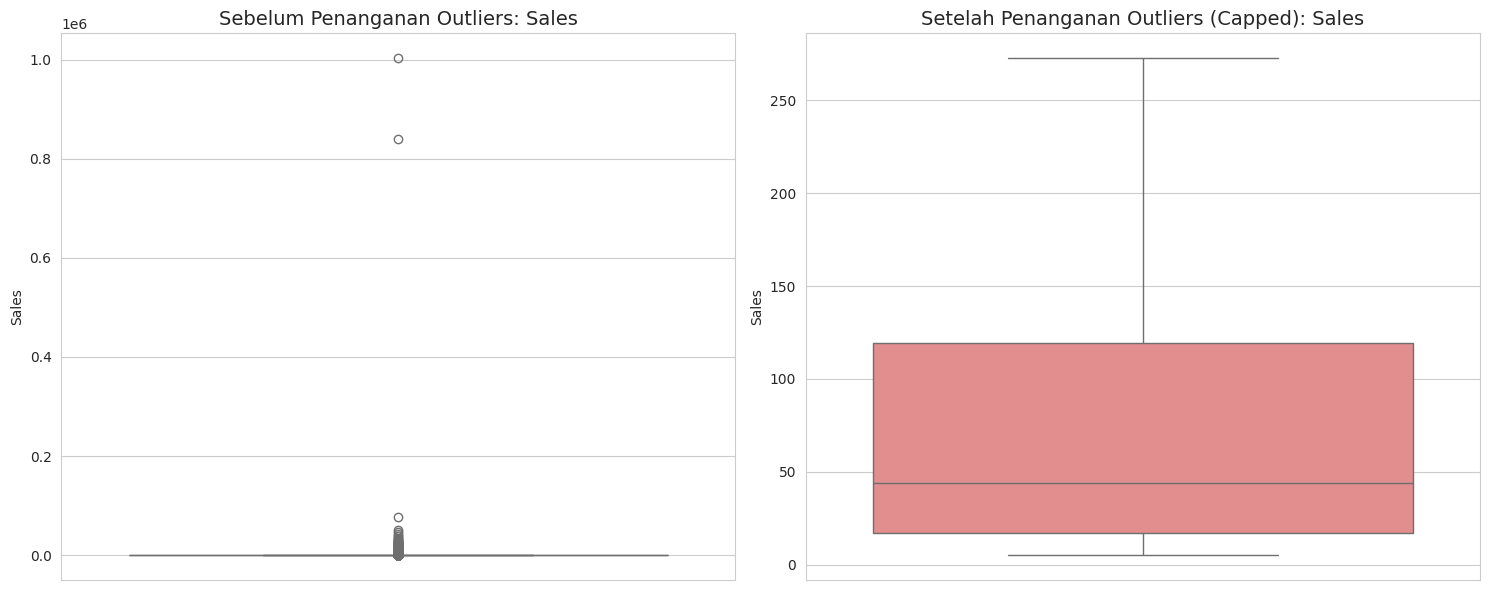



Visualisasi Penanganan Outliers (UnitPrice)


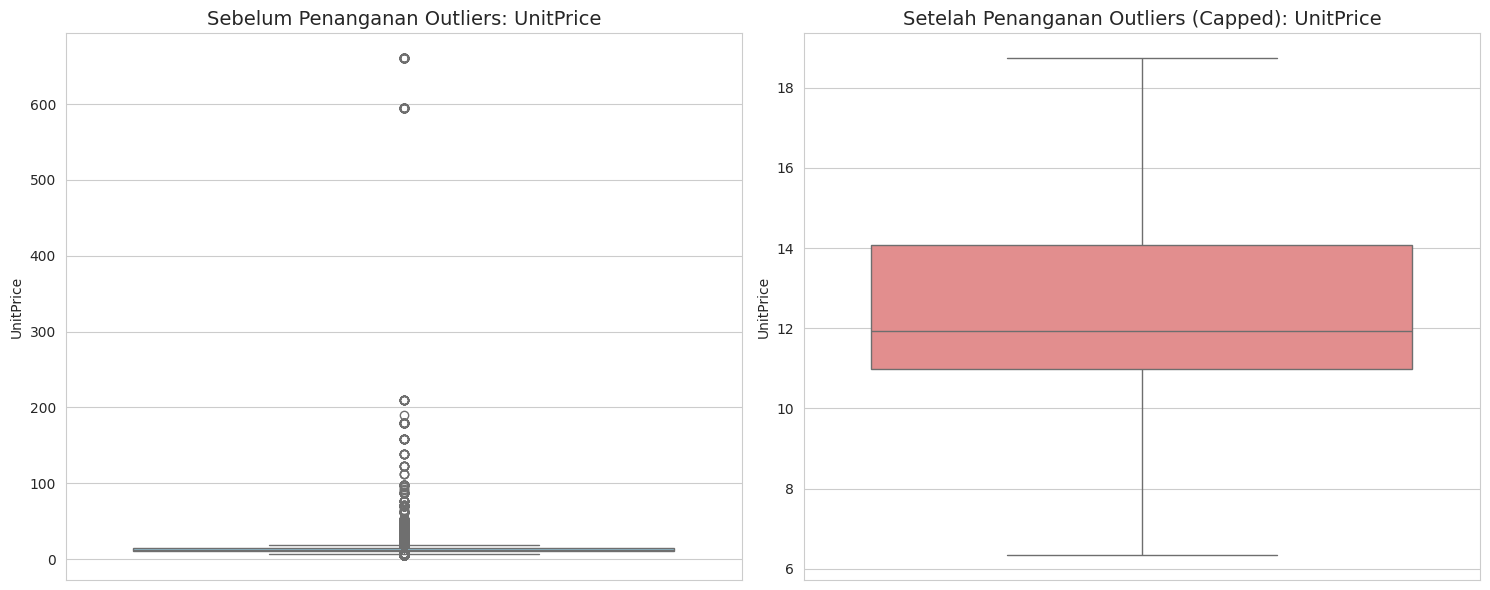



Visualisasi Pengecekan


In [ ]:
if df_cleaned is not None:
    # Daftar kolom yang akan ditangani outliers-nya
    outlier_cols = ['Quantity', 'UnitPrice', 'Sales']

    df_outlier_handled = df_cleaned.copy()

    # Iterasi untuk menangani outliers di setiap kolom
    for col in outlier_cols:
        # Terapkan capping
        df_temp, lower, upper = handle_outliers_capping(df_outlier_handled, col)

        # Perbarui DataFrame dengan nilai yang sudah di-capping
        df_outlier_handled[col] = df_temp[col]

        print(f"Penanganan Outliers untuk '{col}'")
        print(f"Batas Bawah (Lower Bound): {lower:.2f}")
        print(f"Batas Atas (Upper Bound): {upper:.2f}")

    # Visualisasi untuk kolom utama: Sales
    print("\nVisualisasi Penanganan Outliers (Sales)")
    visualize_outliers_handling(df_cleaned, df_outlier_handled, 'Sales')

    # Visualisasi untuk kolom Price (UnitPrice)
    print("\nVisualisasi Penanganan Outliers (UnitPrice)")
    visualize_outliers_handling(df_cleaned, df_outlier_handled, 'UnitPrice')

    df_cleaned = df_outlier_handled.copy()
    print("\nVisualisasi Pengecekan")
else:
    print("Tidak dapat melanjutkan Penanganan Outliers.")


Visualisasi Penanganan Outliers (Quantity)


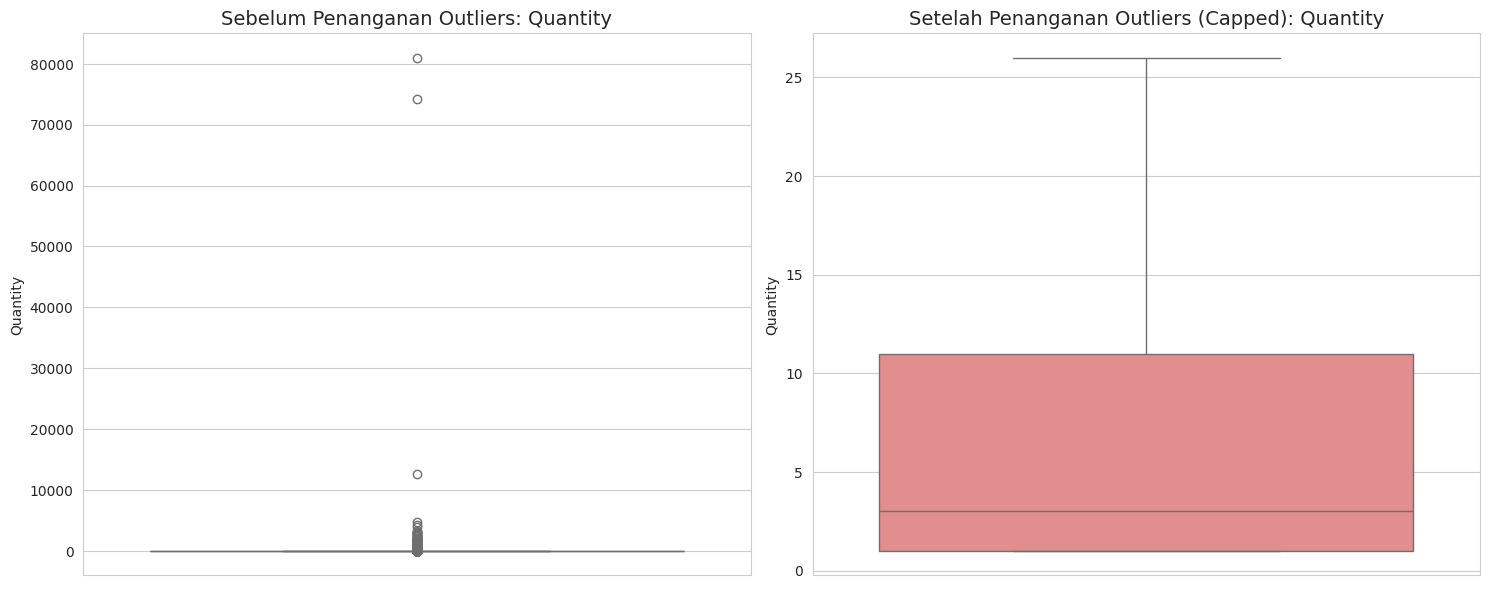



Visualisasi penanganan outliers untuk Quantity telah ditampilkan.


In [ ]:
if 'df_cleaned' in locals() and df_cleaned is not None:
    print("\nVisualisasi Penanganan Outliers (Quantity)")
    df_original_pre_capping = df_purchases.copy()
    df_after_capping = df_cleaned.copy()
    df_before_capping = df_purchases.copy()

    visualize_outliers_handling(df_before_capping, df_after_capping, 'Quantity')

    print("\nVisualisasi penanganan outliers untuk Quantity telah ditampilkan.")
else:
    print("Tidak dapat menampilkan visualisasi karena variabel DataFrame (df_cleaned atau df_purchases) tidak ditemukan.")

# Eksplorasi Data Awal (EDA)

## Statistik Deskriptif Akhir

In [ ]:
if df_cleaned is not None:
    print("Eksplorasi Data Awal (EDA)")

    # Statistik Deskriptif Akhir
    print("\nStatistik Deskriptif Kolom Numerik (Setelah Pembersihan dan Capping)")
    print(df_cleaned[['Quantity', 'UnitPrice', 'Sales']].describe())

Eksplorasi Data Awal (EDA)

Statistik Deskriptif Kolom Numerik (Setelah Pembersihan dan Capping)
            Quantity      UnitPrice          Sales
count  527765.000000  527765.000000  527765.000000
mean        6.900020      12.286417      77.665359
std         7.560179       3.302872      80.273004
min         1.000000       6.340000       5.130000
25%         1.000000      10.990000      17.170000
50%         3.000000      11.940000      43.830000
75%        11.000000      14.090000     119.400000
max        26.000000      18.740000     272.745000


## Distribusi Sales Amount

Eksplorasi Data Awal (EDA)


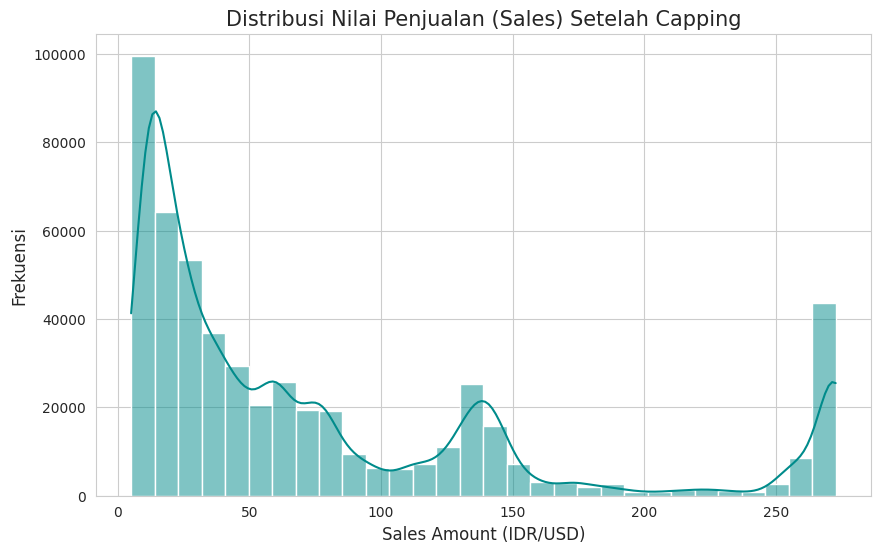

In [ ]:
if df_cleaned is not None:
    print("Eksplorasi Data Awal (EDA)")
# Distribusi Sales Amount
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned['Sales'], bins=30, kde=True, color='darkcyan')
    plt.title('Distribusi Nilai Penjualan (Sales) Setelah Capping', fontsize=15)
    plt.xlabel('Sales Amount (IDR/USD)', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.show()

## Analisis Produk Teratas (Top 10) berdasarkan Volume Penjualan (Sales)

/tmp/ipython-input-2070900589.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_sales.index, y=top_products_sales.values, palette='magma')


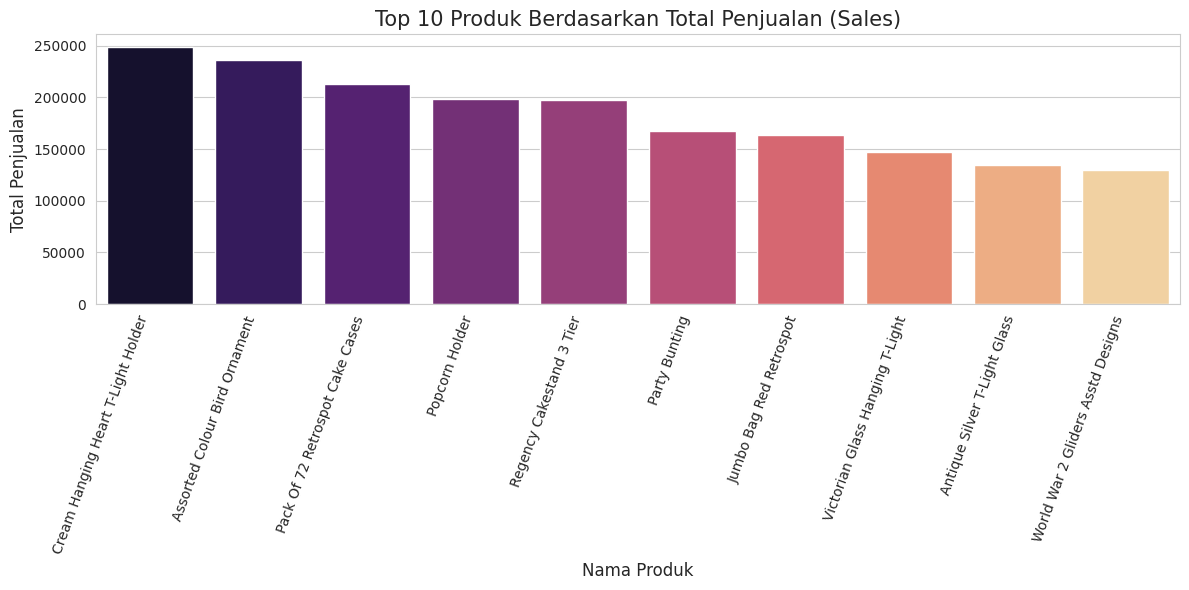

In [ ]:
if df_cleaned is not None:
# Analisis Produk Teratas (Top 10) berdasarkan Volume Penjualan (Sales)
    top_products_sales = df_cleaned.groupby('Description')['Sales'].sum().nlargest(10).sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_products_sales.index, y=top_products_sales.values, palette='magma')
    plt.title('Top 10 Produk Berdasarkan Total Penjualan (Sales)', fontsize=15)
    plt.xlabel('Nama Produk', fontsize=12)
    plt.ylabel('Total Penjualan', fontsize=12)
    plt.xticks(rotation=70, ha='right')
    plt.tight_layout()
    plt.show()

## Analisis Negara dengan Penjualan Tertinggi

/tmp/ipython-input-1154880454.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_revenue.index, y=top_countries_revenue.values, palette='viridis')


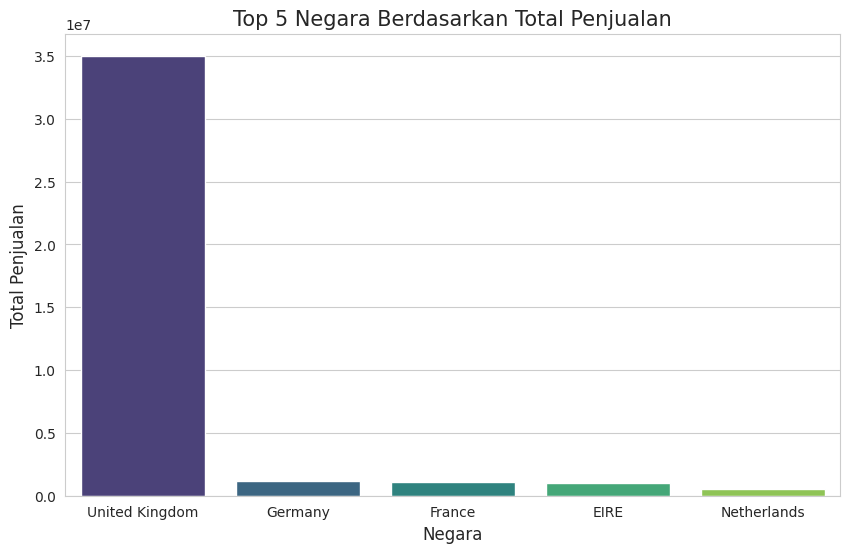

In [ ]:
if df_cleaned is not None:
  # Analisis Negara dengan Penjualan Tertinggi
    top_countries_revenue = df_cleaned.groupby('Country')['Sales'].sum().nlargest(5)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_countries_revenue.index, y=top_countries_revenue.values, palette='viridis')
    plt.title('Top 5 Negara Berdasarkan Total Penjualan', fontsize=15)
    plt.xlabel('Negara', fontsize=12)
    plt.ylabel('Total Penjualan', fontsize=12)
    plt.show()

## Tren Penjualan dari Waktu ke Waktu

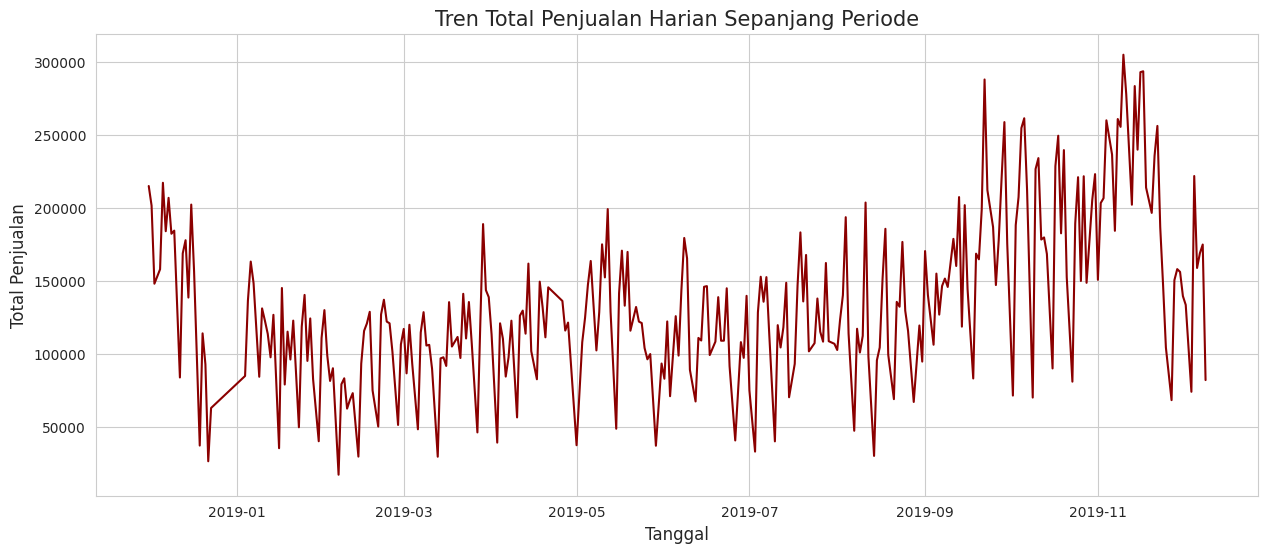

In [ ]:
if df_cleaned is not None:
    # 4.5 Tren Penjualan dari Waktu ke Waktu
    # Agregasi data harian
    df_cleaned['Invoice_Day'] = df_cleaned['InvoiceDate'].dt.date
    daily_sales = df_cleaned.groupby('Invoice_Day')['Sales'].sum()

    plt.figure(figsize=(15, 6))
    daily_sales.plot(kind='line', color='darkred')
    plt.title('Tren Total Penjualan Harian Sepanjang Periode', fontsize=15)
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Total Penjualan', fontsize=12)
    plt.show()

# Export Data

In [ ]:
if 'df_cleaned' in locals() and df_cleaned is not None:
    output_csv_filename = 'Sales_Transaction_Cleaned.csv'

    # index=False agar indeks DataFrame tidak ikut tersimpan sebagai kolom
    df_cleaned.to_csv(output_csv_filename, index=False)
    print(f"Data Cleaned berhasil diexport ke file: {output_csv_filename}")

else:
    print("Variabel 'df_cleaned' tidak ditemukan.")

Data Cleaned berhasil diexport ke file: Sales_Transaction_Cleaned.csv
